In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
class LogisticRegression:
    def __init__(self, epochs=1000, learning_rate=0.01):
        self.epochs = epochs
        self.learning_rate = 0.01
        self.w = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def predict_proba(self, X):
        z = np.dot(X, self.w)
        y_pred = self.sigmoid(z)
        return y_pred
    
    def binary_cross_entropy(self, y, y_pred):
        loss = y*np.log(y_pred) + (1.0 - y)*np.log(1.0 - y_pred)
        return -np.mean(loss)

    def predict(self, X, threshold=0.5):
        y_pred = self.predict_proba(X)

        y[y_pred >= threshold] = 1.0
        y[y_pred < threshold] = 0.0

        return y_pred

    def grad(self, X, y, y_pred):
        n_sample = X.shape[0]
        dw = np.dot(X.T, (y_pred - y))
        return (-1/n_sample) *dw
        
    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        losses = []

        for epoch in range(self.epochs):
            z = np.dot(X, self.w)
            y_pred = self.sigmoid(z)

            dw = self.grad(X, y, y_pred)

            self.w -= dw*self.learning_rate
            loss = self.binary_cross_entropy(y, y_pred)
            losses.append(loss)

            if epoch % 100 == 0:
                print(f"epoch {epoch}, loss {loss}")

        return losses

In [3]:
class LogisticRegression:
    def __init__ (self, lr=0.01, num_iter=1000, shuffle=True, batch_size=32):
        self.lr = lr
        self.num_iter = num_iter
        self.shuffle = shuffle
        self.batch_size = batch_size
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
       return 1 / (1 + np.exp(-z))

    def binary_cross_entropy(self, y_true, y_pred):
        epsilon = 1e-9 
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred)
        return -np.mean(loss)

    def grad(self, X, y_true, y_pred):
        n_samples = X.shape[0]
        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_true))
        db = (1 / n_samples) * np.sum(y_pred - y_true)
        return dw, db


    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(z)
        return y_pred

    def predict(self, X, threshold=0.5):
        y_pred = self.predict_proba(X)
        y_pred[y_pred >= threshold] = 1.0
        y_pred[y_pred < threshold] = 0.0
        return y_pred

    def batch_generator(self, X, y):
        if self.shuffle:
            idx = np.random.permutation(len(y))
            X, y = X[idx], y[idx]
        
        for i in range(0, len(y), self.batch_size):
            yield X[i : i+self.batch_size], y[i : i+self.batch_size]

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        
        for _ in range(self.num_iter):

            for X_batch, y_batch in self.batch_generator(X, y):
                z = np.dot(X_batch, self.weights) + self.bias
                y_pred = self.sigmoid(z)
                
                dw, db = self.grad(X_batch, y_batch, y_pred)

                self.weights -= self.lr * dw
                self.bias -= self.lr * db
            if _ % 100 == 0:
                full_pred = self.predict_proba(X)
                print(f"Epoch {_} - Loss: {self.binary_cross_entropy(y, full_pred):.4f}")

        return self.weights, self.bias

In [4]:
class LogisticRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def predict_proba(self, X):
        z = np.dot(X, self.w.T)
        y_pred = self.sigmoid(z)
        return y_pred

    def predict(self, X, threshold=0.5):
        y_pred = self.predict_proba(X)
        return (y_pred >= threshold).astype(float)
    
    def binary_cross_entropy(self, y, y_pred):
        epsilon = 1e-9 
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = y*np.log(y_pred) + (1.0 - y)*np.log(1.0 - y_pred)
        return -np.mean(loss)
    
    def grad(self, X, y, y_pred):
        n_sample = X.shape[0]
        dw = np.dot(X.T, (y_pred - y))
        return 1/n_sample * dw

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        losses = []

        for epoch in range(self.epochs):
            z = np.dot(X, self.w.T)
            y_pred = self.sigmoid(z)

            dw = self.grad(X, y, y_pred)
            self.w -= self.lr*dw

            loss = self.binary_cross_entropy(y, y_pred)
            losses.append(loss)

            if epoch % 100 == 0:
                print(f"epoch {epoch}, loss {loss}")

        return losses

In [5]:
def scaled(X):
    return (X - X.min()) / (X.max() - X.min())

In [6]:
def evaluate(model, X, y_true):
    y_pred = model.predict(X, threshold=0.36)

    accuracy = np.mean(y_true == y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 0) & (y_pred == 0)) 
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score  = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1_score:.2f}")

In [7]:
data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
X = data[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']].values
y = data['Outcome'].values

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN

smote = SMOTE(random_state=42,
              k_neighbors=5 )
X_new, y_new = smote.fit_resample(X, y)

# ada = ADASYN(random_state=42,
#              n_neighbors=5)
# X_new, y_new = ada.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36)

scaler = StandardScaler()
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)

In [10]:
model = LogisticRegression()
losses = model.fit(X_train, y_train)

y_pred = model.predict(X_test, threshold=0.36)
evaluate(model, X_test, y_test)

epoch 0, loss 0.6931471805599453
epoch 100, loss 0.6190731699535285
epoch 200, loss 0.5845686763763025
epoch 300, loss 0.5660944765019623
epoch 400, loss 0.5550405958175486
epoch 500, loss 0.5478688009892493
epoch 600, loss 0.5429338874535904
epoch 700, loss 0.5393878311062361
epoch 800, loss 0.5367555173344487
epoch 900, loss 0.534752165918062
Accuracy: 64.94%
Precision: 0.49
Recall: 0.92
F1 Score: 0.64


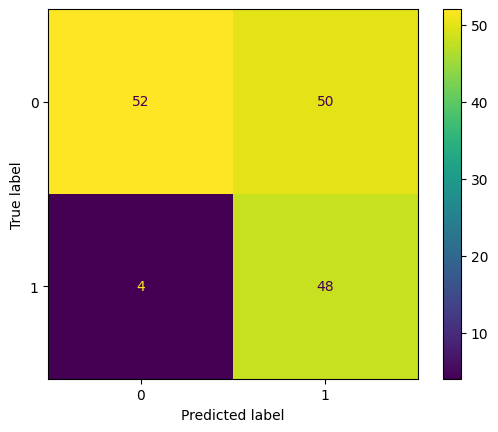

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()